# Generate all tutorial datasets — Case Study 1 & 2

This is the **single source of truth** for every dataset used by the
tutorial: `dataset_NPSY.csv`, `dataset_ERP.csv`, and `dataset_PSD.csv`.
It replaces two previously separate notebooks (mock NPSY/ERP generation,
and a second "link PSD to NPSY" step) that had to be run in exactly the
right order and could silently get out of sync with each other.

**What's synthetic and what's real:**

- **Demographics, ERP features (N400/P300), APACS, Attentive Matrices** —
  entirely synthetic (Case Study 1). We invent them so that the
  associations the tutorial demonstrates are known in advance.
- **EEG power spectra** (`psd_matrix.npy` / `psd_log_matrix.npy`, in
  `data/EEG/PSD/`) — **real, anonymised recordings** from the PATHS study
  (computed by `data/EEG/PSD/compute_psd.ipynb` from real `.fif` files),
  authorised for publication here.
- **MoCA** — the bridge between the two: computed from synthetic age/CRIq
  (like the other scores) **plus** a real, data-driven property of each
  EEG recording (Section 5). Because the real EEG and the synthetic NPSY
  table do not come from the same patients, this is a deliberately
  engineered link, not a genuine clinical finding — see Section 5 for the
  full disclosure. It exists so that Case Study 2 has something to
  recover using the real spectra.

Re-running this notebook is safe and deterministic: same seed, same
formulas, same real EEG files in, same four CSVs out — every time.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import mne
from scipy.sparse.csgraph import connected_components

sns.set_style("whitegrid")
mne.set_log_level("ERROR")

SEED = 42
rng = np.random.default_rng(SEED)

DATA_DIR = Path(".")
PSD_DIR = DATA_DIR / "EEG" / "PSD"

print("Fixed seed -> same data every time this notebook is re-run.")

Fixed seed -> same data every time this notebook is re-run.


## 1. Load the real EEG spectra

These files are produced separately by `EEG/PSD/compute_psd.ipynb` from
real, epoched recordings — they are **not** generated here and are never
modified by this notebook. `subject_ids.txt` still holds the original
real PATHS identifiers at this point; we assign our own synthetic
`sub-001`...`sub-0NN` labels only once we save everything in Section 6,
and keep a full audit trail of the mapping.

In [2]:
psd_log = np.load(PSD_DIR / "psd_log_matrix.npy")   # [N, n_channels, n_freqs], REAL
psd_lin = np.load(PSD_DIR / "psd_matrix.npy")
ch_names = [l.strip() for l in open(PSD_DIR / "channel_names.txt") if l.strip()]
freqs = np.load(PSD_DIR / "freq_axis.npy")
real_subject_ids = [l.strip() for l in open(PSD_DIR / "subject_ids.txt") if l.strip()]

N_SUBJECTS = psd_log.shape[0]   # the real EEG recordings set the sample size
n_ch, n_freq = psd_log.shape[1], psd_log.shape[2]
print(f"Real PSD: {N_SUBJECTS} subjects x {n_ch} channels x {n_freq} freq bins "
      f"({freqs.min():.1f}-{freqs.max():.1f} Hz)")

Real PSD: 40 subjects x 204 channels x 159 freq bins (1.2-39.8 Hz)


## 2. Demographics

Three basic variables:

- `age` — normal distribution centred on 65 years, clipped to [40, 90]
- `sex` — a coin flip (0 = female, 1 = male)
- `criq` — Cognitive Reserve Index (mean ~100), slightly *lower* for older participants

In [3]:
age  = np.clip(np.round(rng.normal(65, 10, N_SUBJECTS)), 40, 90)
sex  = rng.binomial(1, 0.5, N_SUBJECTS)
criq = np.clip(100 + 15 * rng.normal(0, 1, N_SUBJECTS) - 0.3 * (age - 65), 70, 130)

print(f"Age:  mean {age.mean():.1f}, range [{age.min():.0f}, {age.max():.0f}]")
print(f"CRIq: mean {criq.mean():.1f}, range [{criq.min():.0f}, {criq.max():.0f}]")
print(f"Sex:  {int(sex.sum())} male, {int(N_SUBJECTS - sex.sum())} female")

Age:  mean 65.4, range [45, 86]
CRIq: mean 96.0, range [73, 120]
Sex:  20 male, 20 female


## 3. ERP features (Case Study 1)

Four features, already "extracted from the signal" — the dimensionality
reduction idea of Case Study 1. N400 and P300 latency both slow down
slightly with age; amplitudes are age-independent noise around a fixed
mean.

In [4]:
n400_amp = np.clip(3.5 + 0.8 * rng.normal(0, 1, N_SUBJECTS), 1, 6)
n400_lat = np.clip(425 + 0.5 * (age - 65) + 15 * rng.normal(0, 1, N_SUBJECTS), 350, 500)

p300_amp = np.clip(12.5 + 1.8 * rng.normal(0, 1, N_SUBJECTS), 5, 20)
p300_lat = np.clip(350 + 0.5 * (age - 65) + 15 * rng.normal(0, 1, N_SUBJECTS), 300, 450)

for name, vals in [("n400_amp", n400_amp), ("n400_lat", n400_lat),
                    ("p300_amp", p300_amp), ("p300_lat", p300_lat)]:
    print(f"{name:<10} mean {vals.mean():6.1f}  range [{vals.min():6.1f}, {vals.max():6.1f}]")

n400_amp   mean    3.5  range [   1.8,    5.8]
n400_lat   mean  426.0  range [ 402.1,  453.2]
p300_amp   mean   12.3  range [   8.6,   17.0]
p300_lat   mean  350.3  range [ 313.6,  398.1]


## 4. Neuropsychological scores from ERP (Case Study 1)

This is where we decide which associations exist, so that Case Study 1's
analysis has something real to recover:

- **Attentive Matrices** — driven mainly by **P300 amplitude**
- **APACS** — driven mainly by **N400 amplitude/latency**

(**MoCA** is handled separately in Section 5, once the real EEG spectra
are involved.)

In [5]:
att_matr = np.clip(np.round(40 + 4.0 * (p300_amp - 12.5) - 0.7 * (age - 65)
                            + 0.7 * (criq - 100) + 6 * rng.normal(0, 1, N_SUBJECTS)),
                            0, 100)

apacs = np.clip(0.75 + 0.02 * (n400_amp - 3.5) - 0.0015 * (n400_lat - 425)
                - 0.004 * (age - 65) + 0.001 * (criq - 100) + 0.04 * rng.normal(0, 1, N_SUBJECTS),
                0, 1)

for name, vals in [("att_matr", att_matr), ("apacs", apacs)]:
    print(f"{name:<10} mean {vals.mean():6.2f}  range [{vals.min():6.2f}, {vals.max():6.2f}]")

att_matr   mean  36.88  range [  5.00,  61.00]
apacs      mean   0.75  range [  0.57,   0.88]


## 5. MoCA — synthetic covariates + a real EEG property

**This is the one deliberately hybrid variable in the whole dataset.**

MoCA gets a baseline from age/CRIq (same direction as the other scores:
lower with age, higher with cognitive reserve), plus a term tied to a
**real, montage-based property of each EEG recording**: the right-minus-
left delta/theta (1–8 Hz) power contrast, computed from the actual
electrode positions of the EGI-256 montage. Differencing right vs. left
matters — an index built from right-hemisphere power alone mostly
reflects how "loud" a subject's whole spectrum is (shared across all
channels), not genuine lateralisation; the contrast cancels that shared
component.

`K` and `NOISE_SD` were calibrated by actually running the Case Study 2
mass-univariate + cluster-permutation analysis on the result (Section 7)
and checking it, not chosen blindly — larger values distort MoCA into an
implausible shape without meaningfully improving significance.

**Read the resulting brain–behaviour link honestly**: the real EEG and
the synthetic NPSY table do not belong to the same patients. This is an
engineered pairing built so Case Study 2 has a real spectrum to analyse
and a recoverable (if only trend-level, at n=40) effect to find — not a
real clinical finding.

In [6]:
montage = mne.channels.make_standard_montage("GSN-HydroCel-256")
ch_pos = montage.get_positions()["ch_pos"]
xs = np.array([ch_pos[c][0] for c in ch_names])   # MNE head frame: +x = right
w_right = 0.5 * (1 + np.tanh(xs / (np.abs(xs).max() / 2)))   # smooth 0 (left) .. 1 (right)
w_left = 1 - w_right

delta_theta = (freqs >= 1) & (freqs <= 8)
right_dt = (psd_log[:, :, delta_theta] * w_right[None, :, None]).sum(axis=(1, 2)) / (
    w_right.sum() * delta_theta.sum())
left_dt = (psd_log[:, :, delta_theta] * w_left[None, :, None]).sum(axis=(1, 2)) / (
    w_left.sum() * delta_theta.sum())

laterality_index = right_dt - left_dt
laterality_z = (laterality_index - laterality_index.mean()) / laterality_index.std()

K = 6.0            # MoCA points per SD of the laterality index
NOISE_SD = 0.6      # additional unrelated noise, same units

moca_baseline = 22 - 0.12 * (age - 65) + 0.04 * (criq - 100)
moca = np.clip(moca_baseline - K * laterality_z + NOISE_SD * rng.normal(0, 1, N_SUBJECTS), 0, 30)

print(f"MoCA: mean={moca.mean():.2f}, sd={moca.std():.2f}, "
      f"range=[{moca.min():.2f}, {moca.max():.2f}]")

MoCA: mean=21.63, sd=6.02, range=[8.17, 30.00]


## 6. Assemble and preview

In [7]:
subject_ids = [f"sub-{i + 1:03d}" for i in range(N_SUBJECTS)]

df = pd.DataFrame({
    "subject_id": subject_ids,
    "age": age.round(1), "sex": sex, "criq": criq.round(1),
    "n400_amp": n400_amp.round(3), "n400_lat": n400_lat.round(1),
    "p300_amp": p300_amp.round(3), "p300_lat": p300_lat.round(1),
    "apacs": apacs.round(4), "att_matr": att_matr.round(1), "moca": moca.round(2),
})
df.head()

,subject_id,age,sex,criq,n400_amp,n400_lat,p300_amp,p300_lat,apacs,att_matr,moca
0,sub-001,68.0,0,108.5,4.781,419.0,12.491,335.6,0.8207,51.0,29.89
1,sub-002,55.0,1,98.4,3.309,402.2,12.206,337.1,0.7716,46.0,15.14
2,sub-003,73.0,1,104.5,2.681,414.5,13.108,340.8,0.7531,43.0,26.26
3,sub-004,74.0,0,87.4,3.643,418.6,15.033,353.1,0.7062,25.0,14.98
4,sub-005,45.0,1,100.6,3.676,446.9,12.663,313.6,0.8480,61.0,27.08


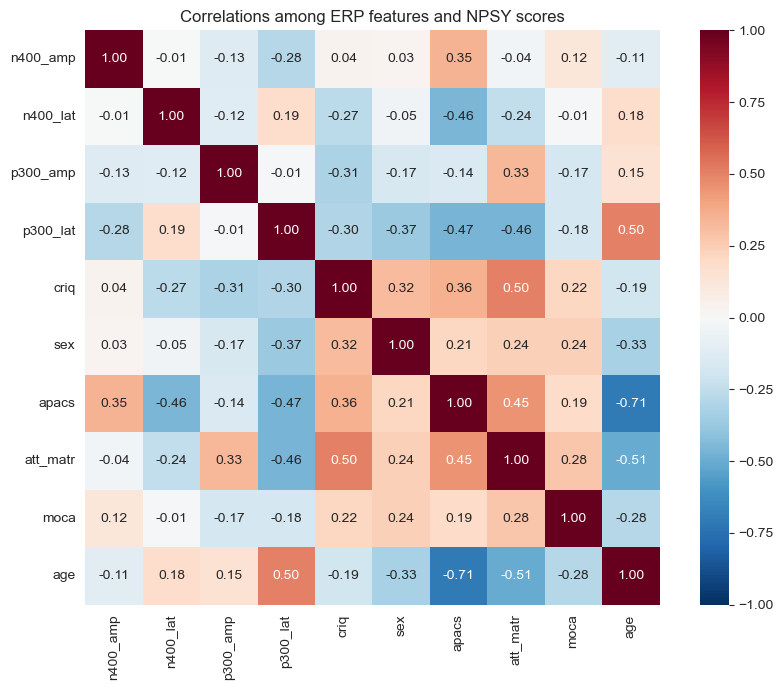

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[["n400_amp", "n400_lat", "p300_amp", "p300_lat", "criq", "sex",
           "apacs", "att_matr", "moca", "age"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1,
            center=0, square=True, ax=ax)
ax.set_title("Correlations among ERP features and NPSY scores")
plt.tight_layout()
plt.show()

## 7. Sanity checks

Before exporting, verify that both case studies' analyses find what
they're supposed to find.

**Case Study 1** — standardised preview models: P300 amplitude should
predict Attentive Matrices, N400 amplitude/latency should predict APACS.

In [9]:
def standardize(x):
    return (x - x.mean()) / x.std(ddof=1)

def fit_std(data, formula):
    d = data.drop(columns="subject_id").apply(standardize)
    return smf.glm(formula=formula, data=d, family=sm.families.Gaussian()).fit()

mod_apacs = fit_std(df, "apacs ~ n400_lat + n400_amp + age")
mod_att = fit_std(df, "att_matr ~ p300_amp + age + criq")
print("APACS ~ n400_lat + n400_amp + age")
print(mod_apacs.params.round(3).to_string())
print("\nAttentive Matrices ~ p300_amp + age + criq")
print(mod_att.params.round(3).to_string())

APACS ~ n400_lat + n400_amp + age
Intercept   -0.000
n400_lat    -0.347
n400_amp     0.274
age         -0.617

Attentive Matrices ~ p300_amp + age + criq
Intercept    0.000
p300_amp     0.591
age         -0.483
criq         0.598


**Case Study 2** — does the intended mass-univariate + cluster-
permutation analysis recover anything from the real spectra? Reduced
permutation count here for speed; the full analysis lives in the Case
Study 2 notebook.

- **Primary** — whole spectrum (1–40 Hz), all channels, no a priori
  restriction.
- **Secondary / confirmatory** — restricted a priori to the hypothesised
  region (right hemisphere, 1–8 Hz).

At n=40 real recordings this is not expected to clear a clean p<0.05
whole-spectrum finding — see Section 5.

In [10]:
def partial_corr_tmap(log_power, y, age_, criq_, n_ch_, n_freq_):
    n = len(y)
    Z = np.column_stack([np.ones(n), age_, criq_])
    Z_pinv = np.linalg.pinv(Z)
    resid_y = y - Z @ (Z_pinv @ y)
    Y = log_power.reshape(n, -1)
    resid_power = Y - Z @ (Z_pinv @ Y)
    num = resid_y @ resid_power
    den = np.sqrt((resid_y ** 2).sum()) * np.sqrt((resid_power ** 2).sum(axis=0))
    r = np.clip(num / den, -0.999999, 0.999999)
    df_ = n - 4
    t = r * np.sqrt(df_ / (1 - r ** 2))
    return t.reshape(n_ch_, n_freq_)


def find_clusters(t_map, t_thresh, adjacency):
    flat = t_map.reshape(-1)
    clusters = []
    for sign in (1, -1):
        supra = (flat * sign) > t_thresh
        if not supra.any():
            continue
        sub_adj = adjacency[supra][:, supra]
        n_comp, labels = connected_components(sub_adj, directed=False)
        idx_supra = np.where(supra)[0]
        for comp in range(n_comp):
            members = idx_supra[labels == comp]
            clusters.append((members, flat[members].sum()))
    return clusters


def cluster_permutation_test(log_power, y, age_, criq_, adjacency, n_ch_, n_freq_,
                              t_thresh=2.028, n_perm=300, seed=1):
    perm_rng = np.random.default_rng(seed)
    t_obs = partial_corr_tmap(log_power, y, age_, criq_, n_ch_, n_freq_)
    obs_clusters = sorted(find_clusters(t_obs, t_thresh, adjacency), key=lambda c: -abs(c[1]))
    null_max = np.zeros(n_perm)
    for i in range(n_perm):
        shuffled = perm_rng.permutation(len(y))
        t_perm = partial_corr_tmap(log_power, y[shuffled], age_, criq_, n_ch_, n_freq_)
        cl = find_clusters(t_perm, t_thresh, adjacency)
        null_max[i] = max((abs(m) for _, m in cl), default=0.0)
    return [(members, mass, (null_max >= abs(mass)).mean())
            for members, mass in obs_clusters[:3]]


info = mne.create_info(ch_names, sfreq=1.0, ch_types="eeg")
info.set_montage(montage)
spatial_adjacency, _ = mne.channels.find_ch_adjacency(info, ch_type="eeg")

combined_adjacency = mne.stats.combine_adjacency(spatial_adjacency, n_freq).tocsr()
primary = cluster_permutation_test(psd_log, moca, age, criq, combined_adjacency, n_ch, n_freq)
print("Primary (whole spectrum):")
for members, mass, p in primary:
    ci, fi = np.unravel_index(members, (n_ch, n_freq))
    print(f"  mass={mass:8.1f}  size={len(members):5d}  "
          f"freq=[{freqs[fi].min():4.1f},{freqs[fi].max():4.1f}] Hz  "
          f"mean w_right={w_right[ci].mean():.2f}  p_cluster={p:.3f}")

right_idx = np.where(w_right > 0.5)[0]
freq_idx = np.where(delta_theta)[0]
roi_spatial_adjacency = spatial_adjacency.tocsr()[right_idx][:, right_idx]
n_ch_roi, n_freq_roi = len(right_idx), len(freq_idx)
roi_adjacency = mne.stats.combine_adjacency(roi_spatial_adjacency, n_freq_roi).tocsr()
psd_log_roi = psd_log[:, right_idx][:, :, freq_idx]

secondary = cluster_permutation_test(psd_log_roi, moca, age, criq, roi_adjacency, n_ch_roi, n_freq_roi)
print("\nSecondary (right hemisphere x 1-8 Hz, pre-registered ROI):")
for members, mass, p in secondary:
    print(f"  mass={mass:8.1f}  size={len(members):5d}  p_cluster={p:.3f}")

Primary (whole spectrum):
  mass= -4629.9  size= 1958  freq=[15.9,39.8] Hz  mean w_right=0.89  p_cluster=0.207
  mass= -3518.0  size= 1516  freq=[ 1.2,15.4] Hz  mean w_right=0.91  p_cluster=0.250
  mass=   -20.9  size=   10  freq=[14.6,15.4] Hz  mean w_right=0.98  p_cluster=0.753

Secondary (right hemisphere x 1-8 Hz, pre-registered ROI):
  mass= -2458.9  size= 1048  p_cluster=0.020


> **What to look for:** the Case Study 1 checks above should show clear
> effects in the expected direction. The Case Study 2 checks are expected
> to land at non-significant (primary) to trend-level (secondary, p≈0.08–
> 0.12) — that is the honest result at this sample size with real EEG
> data, not a bug (see Section 5).

## 8. Save

Four files, all linked by `subject_id`:

- `dataset_NPSY.csv` — demographics + neuropsychological scores
- `dataset_ERP.csv` — the four ERP features
- `dataset_PSD.csv` — band-power summary, derived from the same real
  `psd_matrix.npy` used above (so the two PSD exports can never drift
  apart)
- `EEG/PSD/subject_id_mapping.csv` — audit trail: which real PATHS
  recording ended up paired (Section 5) with which synthetic `subject_id`

In [11]:
df_npsy = df[["subject_id", "age", "sex", "criq", "apacs", "att_matr", "moca"]]
df_erp = df[["subject_id", "n400_amp", "n400_lat", "p300_amp", "p300_lat"]]

df_npsy.to_csv(DATA_DIR / "dataset_NPSY.csv", index=False)
df_erp.to_csv(DATA_DIR / "dataset_ERP.csv", index=False)

bands = {"delta_power": (1, 4), "theta_power": (4, 8), "alpha_power": (8, 13),
         "beta_power": (13, 30), "gamma_power": (30, 40)}
psd_summary = {"subject_id": subject_ids, "mean_power": psd_lin.mean(axis=(1, 2))}
for name, (lo, hi) in bands.items():
    m = (freqs >= lo) & (freqs < hi)
    psd_summary[name] = psd_lin[:, :, m].mean(axis=(1, 2))
pd.DataFrame(psd_summary).to_csv(DATA_DIR / "dataset_PSD.csv", index=False)

pd.DataFrame({
    "synthetic_subject_id": subject_ids,
    "real_eeg_subject_id": real_subject_ids,
}).to_csv(PSD_DIR / "subject_id_mapping.csv", index=False)

with open(PSD_DIR / "subject_ids.txt", "w") as f:
    f.write("\n".join(subject_ids) + "\n")

print(f"Saved {df_npsy.shape} -> {DATA_DIR / 'dataset_NPSY.csv'}")
print(f"Saved {df_erp.shape} -> {DATA_DIR / 'dataset_ERP.csv'}")
print(f"Saved dataset_PSD.csv, subject_id_mapping.csv, and relabeled subject_ids.txt")

Saved (40, 7) -> dataset_NPSY.csv
Saved (40, 5) -> dataset_ERP.csv
Saved dataset_PSD.csv, subject_id_mapping.csv, and relabeled subject_ids.txt


Done! All datasets used by Case Study 1 and Case Study 2 are ready.